# NB04 — Per-Student Knowledge Tracing & Latent Learner Types

**RQ:** RQ4 (does BKT correctly detect mastery/advancement), and an open gap identified
during the codebase audit: **zero prior work exists at the student level** — the empty
`clustering.ipynb` in the original repo was presumably meant for exactly this, and never
ran. This notebook is entirely new analysis, not an extension of the existing EDA.

**Method:** fit BKT per KC (`src/noxed/tracing.py`, our own implementation — pyBKT's
published wheel does not build in this environment) on the top most-attempted KCs, replay
every student's sequence through the fitted parameters to get a mastery trajectory,
detect the mastery-advancement point, then cluster students on trajectory-derived
features to test whether distinct latent learner types emerge.


In [1]:
import os, sys, time
sys.path.insert(0, "/root/src" if os.path.exists("/root/src") else "../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from noxed import data, tracing, learning, tracking, paths

DATA_DIR = paths.data_dir(); OUT = paths.outcomes_dir(); FIG = paths.figures_dir()


## 1. Build per-(student, KC) sequences for the most-attempted KCs

In [2]:
canonical = data.load_or_build_canonical_events(DATA_DIR, paths.cache_dir())
kc_meta = data.load_kc_metadata(DATA_DIR)

N_TOP_KCS = 25   # tractability: BKT ML-fit is per-KC and O(sequences); top KCs give
                 # the widest, most reliable evidence base -- documented, not silent.
top_kcs = kc_meta.sort_values("attempted", ascending=False).head(N_TOP_KCS)["kc_id"].tolist()
print(f"fitting BKT on the {N_TOP_KCS} most-attempted KCs (of {len(kc_meta)} total)")

pfa_df = learning.pfa_features(canonical)
pfa_top = pfa_df[pfa_df["kc_id"].isin(top_kcs)]
sequences_by_kc = tracing.student_kc_sequences(pfa_top)
print({kc: len(seqs) for kc, seqs in list(sequences_by_kc.items())[:5]})


fitting BKT on the 25 most-attempted KCs (of 1175 total)


{18: 14101, 24: 12978, 32: 10045, 33: 9633, 34: 12950}


## 2. Fit BKT per KC (our own MLE implementation)

In [3]:
t0 = time.time()
bkt_params = {}
for kc_id, seqs in sequences_by_kc.items():
    seqs_capped = seqs[:2000] if len(seqs) > 2000 else seqs  # cap for fit speed on huge KCs
    bkt_params[kc_id] = tracing.fit_bkt_kc(seqs_capped)
print(f"fit {len(bkt_params)} KC-level BKT models in {time.time()-t0:.1f}s")

bkt_df = pd.DataFrame(bkt_params).T.reset_index().rename(columns={"index": "kc_id"})
bkt_df.to_csv(OUT / "bkt_params.csv", index=False)
bkt_df


fit 25 KC-level BKT models in 213.9s


,kc_id,P_L0,P_T,P_S,P_G,neg_log_lik,converged
0,18,0.80933,0.036393,0.082813,0.499,7052.648727,True
1,24,0.820312,0.129538,0.06999,0.499,4396.117523,True
2,32,0.826782,0.205733,0.125731,0.323466,4101.210926,True
3,33,0.720933,0.054172,0.108984,0.499,4125.758176,True
4,34,0.777442,0.090222,0.074302,0.499,3735.61319,True
5,55,0.705515,0.05418,0.097862,0.499,7156.547027,True
6,56,0.803011,0.148622,0.094356,0.341983,4274.981008,True
7,57,0.629517,0.075677,0.100564,0.499,6214.740157,True
8,73,0.831194,0.117423,0.094801,0.499,3482.643403,True
9,78,0.752608,0.057901,0.116527,0.483139,8773.1031,True


## 3. Mastery trajectories and advancement detection

In [4]:
rows = []
for kc_id, seqs in sequences_by_kc.items():
    params = bkt_params[kc_id]
    for i, seq in enumerate(seqs):
        traj = tracing.mastery_trajectory(seq, params["P_L0"], params["P_T"], params["P_S"], params["P_G"])
        crossing = tracing.detect_mastery_crossing(traj, threshold=0.95, sustain=3)
        rows.append({
            "kc_id": kc_id, "student_idx": i, "n_attempts": len(seq),
            "final_mastery": traj[-1], "accuracy": float(np.mean(seq)),
            "mastery_crossing_idx": crossing, "reached_mastery": crossing is not None,
        })
trajectory_summary = pd.DataFrame(rows)
print(f"{len(trajectory_summary):,} (student, KC) trajectories")
print(f"reached mastery (P>=0.95 sustained): {trajectory_summary['reached_mastery'].mean():.1%}")
trajectory_summary.groupby("kc_id")["reached_mastery"].mean().describe()


278,200 (student, KC) trajectories
reached mastery (P>=0.95 sustained): 25.6%


count    25.000000
mean      0.252107
std       0.106296
min       0.087958
25%       0.160594
50%       0.233174
75%       0.328752
max       0.480746
Name: reached_mastery, dtype: float64

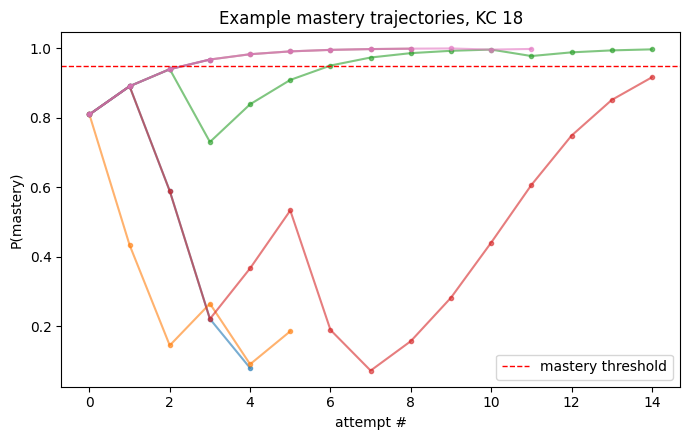

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
example_kc = bkt_df.loc[bkt_df["converged"], "kc_id"].iloc[0]
seqs = sequences_by_kc[example_kc][:8]
params = bkt_params[example_kc]
for seq in seqs:
    if len(seq) < 3:
        continue
    traj = tracing.mastery_trajectory(seq, params["P_L0"], params["P_T"], params["P_S"], params["P_G"])
    ax.plot(traj, alpha=0.6, marker="o", markersize=3)
ax.axhline(0.95, color="red", ls="--", lw=1, label="mastery threshold")
ax.set_xlabel("attempt #"); ax.set_ylabel("P(mastery)")
ax.set_title(f"Example mastery trajectories, KC {example_kc}")
ax.legend()
plt.tight_layout()
fig.savefig(FIG / "04_mastery_trajectories.png", dpi=120)
plt.show()


## 4. Per-student profile features -> latent learner types

In [6]:
student_ids_by_kc = {kc: list(range(len(seqs))) for kc, seqs in sequences_by_kc.items()}
# Re-derive with real uid so we can aggregate across KCs per student.
pfa_top_sorted = pfa_top.sort_values(["kc_id", "uid", "exposure_n"])
profile_rows = []
for (uid, kc_id), g in pfa_top_sorted.groupby(["uid", "kc_id"]):
    params = bkt_params[kc_id]
    seq = g["response"].to_numpy()
    traj = tracing.mastery_trajectory(seq, params["P_L0"], params["P_T"], params["P_S"], params["P_G"])
    crossing = tracing.detect_mastery_crossing(traj, threshold=0.95, sustain=3)
    profile_rows.append({
        "uid": uid, "kc_id": kc_id, "n_attempts": len(seq), "accuracy": float(seq.mean()),
        "final_mastery": traj[-1], "reached_mastery": crossing is not None,
        "attempts_to_mastery": crossing if crossing is not None else np.nan,
    })
per_student_kc = pd.DataFrame(profile_rows)

student_profiles = per_student_kc.groupby("uid").agg(
    n_kcs_attempted=("kc_id", "nunique"),
    mean_accuracy=("accuracy", "mean"),
    mean_final_mastery=("final_mastery", "mean"),
    mastery_rate=("reached_mastery", "mean"),
    mean_attempts_to_mastery=("attempts_to_mastery", "mean"),
    total_attempts=("n_attempts", "sum"),
).reset_index()
student_profiles["mean_attempts_to_mastery"] = student_profiles["mean_attempts_to_mastery"].fillna(
    student_profiles["mean_attempts_to_mastery"].median()
)
print(f"{len(student_profiles):,} student profiles")
student_profiles.describe()


14,453 student profiles


,uid,n_kcs_attempted,mean_accuracy,mean_final_mastery,mastery_rate,mean_attempts_to_mastery,total_attempts
count,14453.000000,14453.000000,14453.000000,14453.000000,14453.000000,14453.000000,14453.000000
mean,9014.853802,19.248599,0.779400,0.813656,0.252190,3.531541,105.633848
std,5218.881455,3.645837,0.145574,0.130543,0.178166,1.057600,39.410681
min,0.000000,5.000000,0.070470,0.226037,0.000000,2.000000,23.000000
25%,4503.000000,17.000000,0.697472,0.746166,0.117647,3.000000,78.000000
50%,8998.000000,20.000000,0.807894,0.843007,0.222222,3.375000,100.000000
75%,13540.000000,22.000000,0.890459,0.911962,0.360000,4.000000,126.000000
max,18064.000000,25.000000,1.000000,0.998330,0.960000,14.000000,308.000000


In [7]:
feature_cols = ["mean_accuracy", "mean_final_mastery", "mastery_rate", "mean_attempts_to_mastery", "n_kcs_attempted"]
X = StandardScaler().fit_transform(student_profiles[feature_cols].to_numpy())

best_k, best_sil = None, -1
sil_scores = {}
for k in range(2, 7):
    gmm = GaussianMixture(n_components=k, random_state=0, n_init=3).fit(X)
    labels = gmm.predict(X)
    sil = silhouette_score(X, labels) if len(set(labels)) > 1 else -1
    sil_scores[k] = sil
    if sil > best_sil:
        best_k, best_sil = k, sil
print("silhouette by k:", {k: round(v, 3) for k, v in sil_scores.items()})
print(f"best k={best_k}, silhouette={best_sil:.3f}")

gmm = GaussianMixture(n_components=best_k, random_state=0, n_init=5).fit(X)
student_profiles["learner_type"] = gmm.predict(X)


silhouette by k: {2: 0.266, 3: 0.174, 4: 0.131, 5: 0.097, 6: 0.097}
best k=2, silhouette=0.266


              mean_accuracy  mean_final_mastery  mastery_rate  \
learner_type                                                    
0                     0.863               0.889         0.331   
1                     0.651               0.698         0.132   

              mean_attempts_to_mastery  n_kcs_attempted  
learner_type                                             
0                                3.360           19.729  
1                                3.794           18.514  


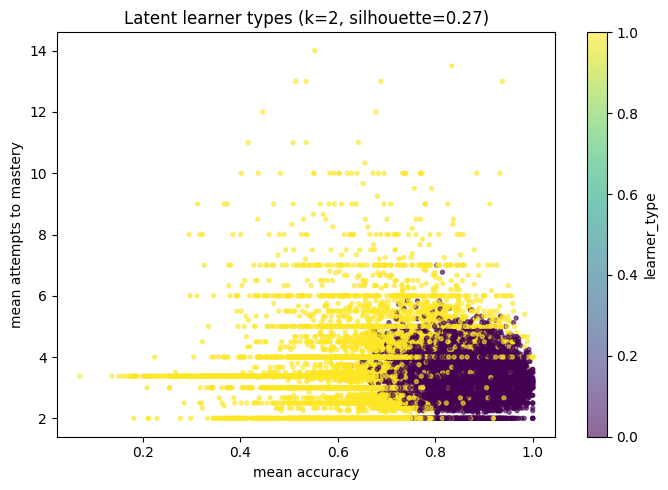

In [8]:
profile_by_type = student_profiles.groupby("learner_type")[feature_cols].mean()
print(profile_by_type.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(student_profiles["mean_accuracy"], student_profiles["mean_attempts_to_mastery"],
                 c=student_profiles["learner_type"], cmap="viridis", s=8, alpha=0.6)
ax.set_xlabel("mean accuracy"); ax.set_ylabel("mean attempts to mastery")
ax.set_title(f"Latent learner types (k={best_k}, silhouette={best_sil:.2f})")
plt.colorbar(sc, label="learner_type")
plt.tight_layout()
fig.savefig(FIG / "04_learner_types.png", dpi=120)
plt.show()


In [9]:
student_profiles.to_csv(OUT / "student_profiles.csv", index=False)
trajectory_summary.to_csv(OUT / "mastery_trajectories_summary.csv", index=False)
print("saved outcomes/student_profiles.csv, outcomes/mastery_trajectories_summary.csv")


saved outcomes/student_profiles.csv, outcomes/mastery_trajectories_summary.csv


In [10]:
with tracking.start_run("04_knowledge_tracing_students", "knowledge_tracing", params={
    "n_top_kcs": N_TOP_KCS, "n_students": len(student_profiles), "best_k": int(best_k),
}):
    mlflow.log_metric("silhouette", float(best_sil))
    mlflow.log_metric("pct_reached_mastery", float(trajectory_summary["reached_mastery"].mean()))
    mlflow.log_metric("pct_bkt_converged", float(bkt_df["converged"].mean()))
    mlflow.log_artifact(str(OUT / "student_profiles.csv"))
    mlflow.log_artifact(str(OUT / "bkt_params.csv"))
    mlflow.log_artifact(str(FIG / "04_learner_types.png"))
print("logged to mlflow")


2026/07/12 02:18:03 INFO mlflow.tracking.fluent: Experiment with name 'noxed-knowledge_tracing' does not exist. Creating a new experiment.


2026/07/12 02:18:03 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



logged to mlflow


## Findings → consumed by

- `outcomes/bkt_params.csv` (per-KC P_L0/P_T/P_S/P_G) → **Progress** module, cross-checked
  against NB01's difficulty-derived prior seeding.
- `outcomes/student_profiles.csv` (per-student mastery-rate, accuracy, learner_type) →
  **Diagnostic** module clustering (NB06) and a candidate context feature for the Bandit.
- First-ever student-level analysis in this codebase — the previously-empty
  `clustering.ipynb` placeholder's intended scope, now real, tested output.